<a href="https://colab.research.google.com/github/arvndms/ICT-DSA_ACTIVITY/blob/main/ICT_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [360]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section A Data Wrangling & Exploratory Analysis

## Q1

In [361]:
#load dataset
df = pd.read_csv('/content/Bengaluru_House_Data.csv')

In [362]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [363]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [364]:
#shape
df.shape

(13320, 9)

In [365]:
#datatype
df.dtypes

,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


In [366]:
#count of missing values
df.isnull().sum()


,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


## Cleaning Dataset

In [367]:
# (a) dropping rows with missing location or size
df = df.dropna(subset=['location','size'])

In [368]:
df.shape

(13303, 9)

In [369]:
# filling missing bath and balcony values with their column medians
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

## Q2

In [370]:
df['bhk'] = df['size'].str.extract(r'(\d+)', expand=False).astype('Int64')

In [371]:
#function to convert total_sqft which has range entires
def convert_to_numeric(value):
    if pd.isna(value):
        return None

    # Convert to string to handle mixed types
    value = str(value).strip()

    # Checking if it's a range
    if '-' in value:
        try:
            parts = value.split('-')
            start = float(parts[0].strip())
            end = float(parts[1].strip())
            return (start + end) / 2
        except:
            return None
    else:
        try:
            return float(value)
        except:
            return None

In [372]:
df['total_sqft'] = df['total_sqft'].apply(convert_to_numeric).astype('Float64')

## Q3

In [373]:
#create new feature price_per_sqft
df['price_per_sqft'] =( df['price'] * 100000) / df['total_sqft']

In [374]:
#before outlier row count
old_row_count = len(df)

location_stats = df.groupby('location')['price_per_sqft'].agg(['mean', 'std']).reset_index()
location_stats.columns = ['location', 'mean_pps', 'std_pps']

# merge this location_stats to df
df = df.merge(location_stats, on='location', how='left')

df['lower'] = df['mean_pps'] - (3 * df['std_pps'])
df['upper'] = df['mean_pps'] + (3 * df['std_pps'])

df['is_outlier'] = (df['price_per_sqft'] < df['lower']) | (df['price_per_sqft'] > df['upper'])


In [375]:
df = df[~df['is_outlier']].copy()
df = df.drop(['mean_pps', 'std_pps', 'lower', 'upper', 'is_outlier'], axis=1)

In [376]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,2,4250.0


 Location wise approach is preferred over a global threshold because Real Estate price depends on the location . Same price/size or facilities varies across tier 1 ,tier 2 , tier 3 cities.So a higher price maybe normal in Tier 1 but it maybe a outlier in Tier 3 .

## Q4

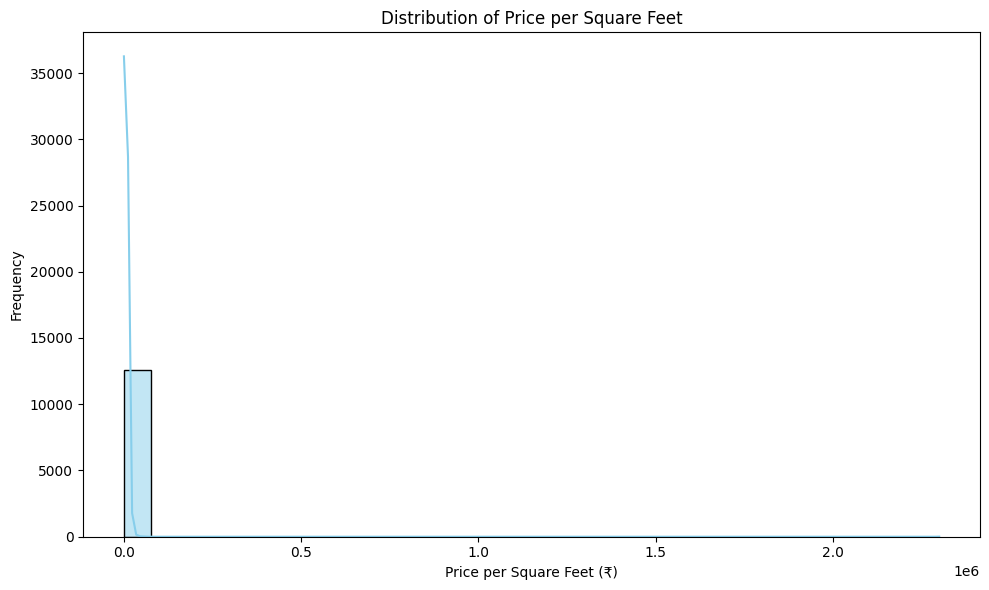

In [377]:
#  price_per_sqft (histogram + KDE overlay)
plt.figure(figsize=(10, 6))
sns.histplot(df['price_per_sqft'], kde=True, bins=30, color='skyblue')
plt.xlabel('Price per Square Feet (₹)')
plt.ylabel('Frequency')
plt.title('Distribution of Price per Square Feet')
plt.tight_layout()
plt.show()

- Heavy Right Skewed data

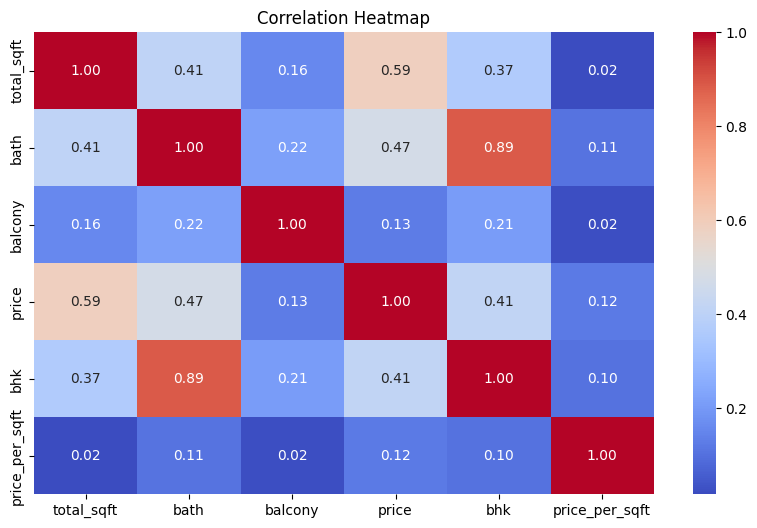

In [378]:
num_cols_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(num_cols_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


- Highest correlation : total_sqft,bath,bhk
- Strong realtion between bhk and bath





Text(0.5, 1.0, 'Box Plot of Price by BHK')

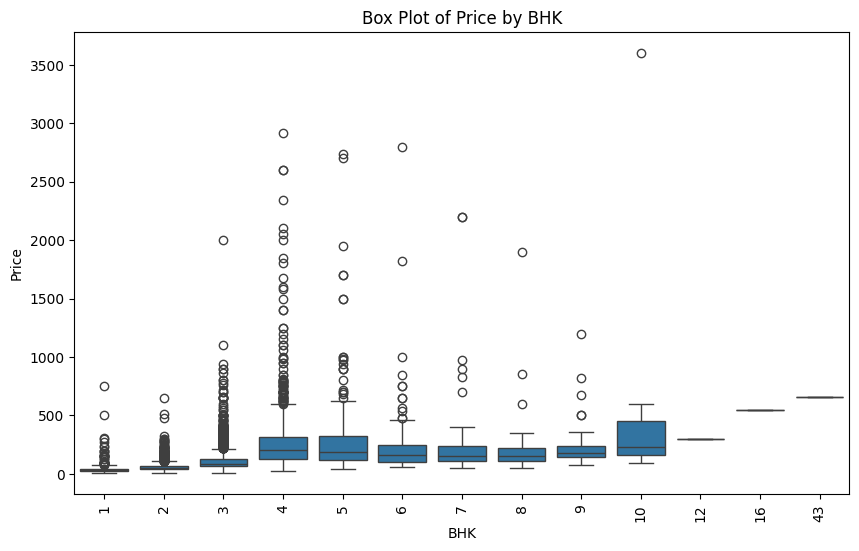

In [379]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bhk', y='price')
plt.xticks(rotation=90)
plt.xlabel('BHK')
plt.ylabel('Price')
plt.title('Box Plot of Price by BHK')


- The boxplot  of price across bhk categories shows that price of house increase with BHK but not perfectly
- 1bhk and 2 bhk have lower median price, 3 to 5 bhk shows a price increase ,above that values are not consistent
- From 3bhk to 5,6bhk some properties are priced way higher than typical range.
- 16bhk,43bhk are unusual values ,it maybe data entry or special cases  

In [380]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore')
area_type_encoded = ohe.fit_transform(df[['area_type']])
area_type_cols = ohe.get_feature_names_out(['area_type'])
area_type_encoded = pd.DataFrame(area_type_encoded, columns=area_type_cols,index=df.index)


In [381]:
area_type_encoded.head()

,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [382]:
top_20_locations = df['location'].value_counts().nlargest(20).index #finds top 20 location

df['location_grouped'] = df['location'].apply(lambda x: x if x in top_20_locations else 'Other') #map all other to other

In [383]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location_grouped'])

In [384]:
final_df = pd.concat([df,area_type_encoded],axis=1)
final_df.drop(['area_type', 'location', 'location_grouped','society','availability','size'], axis=1, inplace=True) # also dropped society which has 5502 missing values ,availability and size

In [385]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
final_df[['total_sqft', 'bath']] = scaler.fit_transform(final_df[['total_sqft', 'bath']])

# Verify scaling worked
print(final_df[['total_sqft','bath']].describe())

         total_sqft          bath
count  12624.000000  12624.000000
mean       0.029653      0.042138
std        0.023657      0.032192
min        0.000000      0.000000
25%        0.020950      0.025641
50%        0.024375      0.025641
75%        0.031937      0.051282
max        1.000000      1.000000


In [386]:
final_df.head()

,total_sqft,bath,balcony,price,bhk,price_per_sqft,location_encoded,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0.020108,0.025641,1.0,39.07,2,3699.810606,5,0.0,0.0,1.0
1,0.049649,0.102564,3.0,120.00,4,4615.384615,13,0.0,1.0,0.0
2,0.027455,0.025641,3.0,62.00,3,4305.555556,18,0.0,0.0,0.0
3,0.029005,0.051282,1.0,95.00,3,6245.890861,13,0.0,0.0,1.0
4,0.022863,0.025641,1.0,51.00,2,4250.0,13,0.0,0.0,1.0


 - One-Hot Encoding : area_type is a nominal category with no
  ordinal relationship between types so using Ohe for encoding.
  - Label Encoding : location, 1000+ unique locations,also grouped rare locations as 'Other' .
  - Min-Max Scaling : Brings both features to [0,1] range,
  preventing large sqft values from dominating distance-based calculations

## Supervised Learning
## Q6

In [387]:
# train_test_split
from sklearn.model_selection import train_test_split
X = final_df.drop(['price','price_per_sqft'],axis=1)
y = final_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [388]:
#linear regressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [389]:
print('R2',r2_score(y_test, y_pred))
print('RMSE',root_mean_squared_error(y_test, y_pred))
print('MAE',mean_absolute_error(y_test, y_pred))

R2 0.4521675722214846
RMSE 103.26773671232903
MAE 41.39806866184037


In [390]:
#Ridge and lasso
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [391]:
print('R2',r2_score(y_test, ridge_pred))
print('RMSE',root_mean_squared_error(y_test, ridge_pred))
print('MAE',mean_absolute_error(y_test, ridge_pred))

R2 0.4530249959584586
RMSE 103.18689184357353
MAE 42.34891516494048


In [392]:
lasso_model = Lasso(alpha=0.01, max_iter=1000)
lasso_model.fit(X_train, y_train)
pred_lasso = lasso_model.predict(X_test)


In [393]:
print('R2',r2_score(y_test,pred_lasso))
print('RMSE',root_mean_squared_error(y_test,pred_lasso))
print('MAE',mean_absolute_error(y_test,pred_lasso))

R2 0.4525258414579355
RMSE 103.23396388127864
MAE 41.37306169236658


-  correlated features can cause multicollinearity, which inflates linear regression coefficients.
- Ridge penalises large coefficients and shrinks correlated features together.
- Lasso can zero out weak features entirely,which act as feature
  selection.

## Q7

In [394]:
final_df['high_value'] = (final_df['price'] >= 100).astype(int)

In [395]:
X_binary = final_df.drop(['high_value','price','price_per_sqft'], axis=1, errors='ignore') #'high_value' 'price_per_sqft' can cause data leakage
y_binary = final_df['high_value']

In [396]:
X_binary.head()

,total_sqft,bath,balcony,bhk,location_encoded,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0.020108,0.025641,1.0,2,5,0.0,0.0,1.0
1,0.049649,0.102564,3.0,4,13,0.0,1.0,0.0
2,0.027455,0.025641,3.0,3,18,0.0,0.0,0.0
3,0.029005,0.051282,1.0,3,13,0.0,0.0,1.0
4,0.022863,0.025641,1.0,2,13,0.0,0.0,1.0


In [397]:
from sklearn.model_selection import train_test_split

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

In [398]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_binary, y_train_binary)
log_pred = log_model.predict(X_test_binary)

In [399]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_binary, y_train_binary)
nb_pred = nb_model.predict(X_test_binary)

In [400]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate(y_test_binary, log_pred, "Logistic Regression")
evaluate(y_test_binary, nb_pred, "Naive Bayes")


Logistic Regression
Accuracy: 0.8023762376237624
Precision: 0.8697674418604651
Recall: 0.45777233782129745
F1 Score: 0.5998396150761829

Naive Bayes
Accuracy: 0.8300990099009901
Precision: 0.7948328267477204
Recall: 0.6401468788249693
F1 Score: 0.7091525423728814


In [401]:
from sklearn.metrics import confusion_matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test_binary, nb_pred))

Logistic Regression Confusion Matrix:
[[1573  135]
 [ 294  523]]


In [402]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_binary, y_train_binary)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [403]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: 0.8870183259039127


In [404]:
best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_binary)

print("Test Accuracy:", accuracy_score(y_test_binary, y_pred_rf))
print("Precision:", precision_score(y_test_binary, y_pred_rf))
print("Recall:", recall_score(y_test_binary, y_pred_rf))
print("F1 Score:", f1_score(y_test_binary, y_pred_rf))

Test Accuracy: 0.8946534653465347
Precision: 0.8564036222509702
Recall: 0.8102815177478581
F1 Score: 0.8327044025157233


##  Unsupervised Learning & Dimensionality Reduction
## Q9

In [405]:
#scailing because k-means is distance based
from sklearn.preprocessing import StandardScaler
features = df[['total_sqft', 'bath', 'price_per_sqft']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [406]:
X_scaled

array([[-0.40349575, -0.51247926, -0.13941318],
       [ 0.84526155,  1.87715564, -0.09728198],
       [-0.09292399, -0.51247926, -0.11153912],
       ...,
       [-0.3347494 , -0.51247926, -0.0676862 ],
       [ 2.53480431,  1.08061067,  0.16924137],
       [-0.81273875, -1.30902423, -0.16743248]])

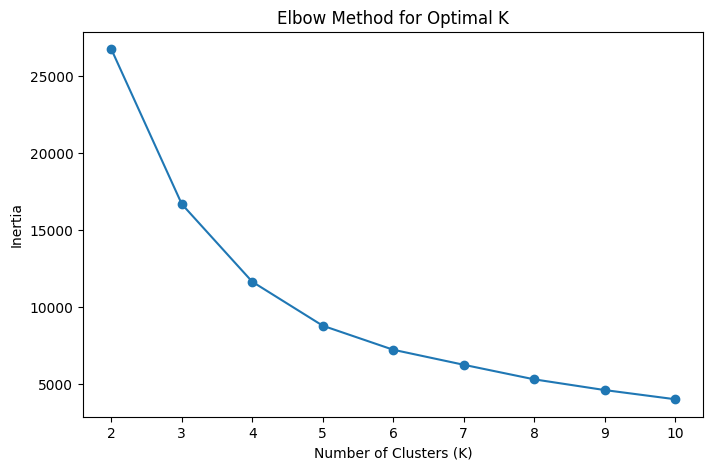

In [407]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [408]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

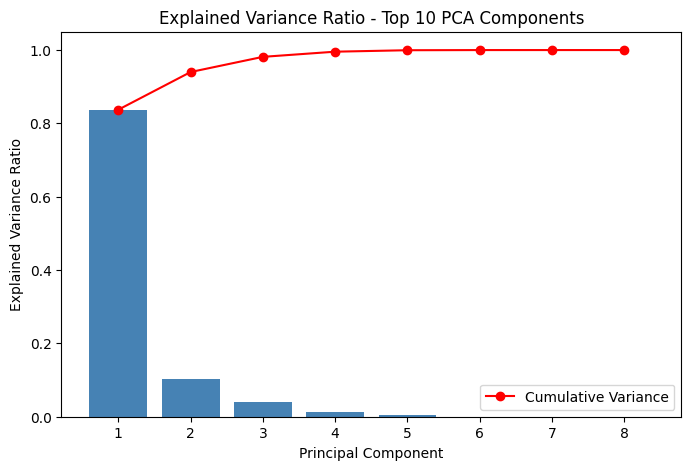

In [409]:
from sklearn.decomposition import PCA
X_pca_input = X_binary.copy()

pca_8 = PCA(n_components=8) # did for 8 components
pca_8.fit(X_pca_input)

#Plot explained variance ratio
plt.figure(figsize=(8, 5))
plt.bar(range(1, 9), pca_8.explained_variance_ratio_, color='steelblue')
plt.plot(range(1, 9), pca_8.explained_variance_ratio_.cumsum(),
         marker='o', color='red', label='Cumulative Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio - Top 10 PCA Components')
plt.legend()
plt.xticks(range(1, 9))
plt.show()

In [410]:
pca_5 = PCA(n_components=5)
X_train_pca = pca_5.fit_transform(X_train_binary)
X_test_pca  = pca_5.transform(X_test_binary)

print("Variance explained by top 5 components:", pca_5.explained_variance_ratio_.sum().round(4))

best_rf_pca = RandomForestClassifier(
    n_estimators=grid.best_params_['n_estimators'],
    max_depth=grid.best_params_['max_depth'],
    random_state=42
)
best_rf_pca.fit(X_train_pca, y_train_binary)
y_pred_pca = best_rf_pca.predict(X_test_pca)

Variance explained by top 5 components: 0.9995


In [411]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Original RF (all features)': [
        round(accuracy_score(y_test_binary, y_pred_rf), 4),
        round(precision_score(y_test_binary, y_pred_rf), 4),
        round(recall_score(y_test_binary, y_pred_rf), 4),
        round(f1_score(y_test_binary, y_pred_rf), 4)
    ],
    'RF with top 5 PCs': [
        round(accuracy_score(y_test_binary, y_pred_pca), 4),
        round(precision_score(y_test_binary, y_pred_pca), 4),
        round(recall_score(y_test_binary, y_pred_pca), 4),
        round(f1_score(y_test_binary, y_pred_pca), 4)
    ]
})


In [412]:
comparison

,Metric,Original RF (all features),RF with top 5 PCs
0,Accuracy,0.8947,0.8764
1,Precision,0.8564,0.8344
2,Recall,0.8103,0.7711
3,F1 Score,0.8327,0.8015


- After Reducing Feature using PCA , we can see a drop in all metric values .
- Original Model is preferred when maximum accuracy is
  the goal

In [413]:
import joblib
joblib.dump(best_rf, 'best_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(ohe, 'one_hot_encoder.pkl')

['one_hot_encoder.pkl']

In [415]:
df[['location', 'bhk', 'total_sqft', 'bath', 'balcony', 'price']].to_csv('chart_data.csv', index=False)
final_df.to_csv('model_data.csv', index=False)